# F1 Strategy Predictor
## Real-Time Pit Stop & Compound Prediction

---

### Obiettivo
**"Predict competitor pit stops in real-time to gain strategic advantage"**

### Il Modello
- **Unidirectional LSTM**: Non usa dati futuri (real-time compatible)
- **Temporal Split**: Train su gare passate, test su gare future
- **Gradient Clipping**: Stabilità del training

### Prerequisiti
- `f1_dataset_clean.pkl` (generato dal notebook DataAnalysis)

# 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
import joblib
import json
import os

os.makedirs('Model', exist_ok=True)
os.makedirs('Other', exist_ok=True)

In [3]:
# FastF1: libreria open-source per dati F1 (telemetria, tempi, meteo)
import importlib.util
if importlib.util.find_spec('fastf1') is None:
    !pip install fastf1 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 8.3 MB/s eta 0:00:00


In [4]:
from sklearn.preprocessing import RobustScaler, LabelEncoder

from sklearn.metrics import (confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score,
                             precision_recall_curve)

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, BatchNormalization,
                                     Masking, MultiHeadAttention,
                                     LayerNormalization, Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponibile: {tf.config.list_physical_devices('GPU')}")

# Riproducibilità
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0
GPU disponibile: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Import Dataset

In [6]:
df_f1 = pd.read_pickle('f1_dataset_clean.pkl')
print(f"Dataset caricato: {len(df_f1):,} righe")

Dataset caricato: 86,757 righe


# 3. Features

In [7]:
FEATURES = [
    'StintProgress', 'GapToLeader', 'UnderCaution', 'Rainfall',
    'WindSpeed', 'Pressure', 'Humidity', 'TrackTemp', 'AirTemp',
    'Round', 'Position', 'FreshTyre', 'TyreLife', 'SpeedST',
    'SpeedFL', 'SpeedI1', 'SpeedI2', 'Stint', 'LapNumber',
    'Sector1TimeSec', 'Sector2TimeSec', 'Sector3TimeSec',
    'OvercutPotential', 'UndercutPotential',
    'IsSoft', 'IsMedium', 'IsHard', 'IsInter',
    'IsPersonalBest', 'DriverEnc', 'TeamEnc', 'LapTimeSec',
    'GapTrend', 'LapTimeTrend3', 'RaceProgress', 'TyreDegradation'
]

---
# 4. Preparazione Dati per Training

In [8]:
# Filtraggio per training
df_clean = df_f1.dropna(subset=['PitIn3Laps', 'NextCompound'])  # Target validi

In [9]:
# Encoding target compound
label_encoder = LabelEncoder()
df_f1['NextCompoundEnc'] = label_encoder.fit_transform(df_f1['NextCompound'])
print(f"\nClassi: {list(label_encoder.classes_)}")


Classi: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']


### 4.1 Creazione Sequenze Temporali

*Perché sequenze di 10 giri?*
L'LSTM ha bisogno di contesto temporale per catturare i trend: 10 giri è un buon compromesso: abbastanza per vedere il degrado, non troppo per includere rumore. Stint più corti vengono paddati con valMedio (il Masking layer li ignorerà)

In [10]:
SEQUENCE_LENGTH = 10  # Giri di storia per la predizione

# Crea sequenze temporali per LSTM
def create_sequences(df, features, target_col, seq_len):
    """
    Crea sequenze temporali per LSTM.
    Input: (samples, timesteps, features) = (N, 10, 14)
    Per ogni giro, prende i 'seq_len' giri precedenti come input.
    """
    X = []  # Input = sequenza di giri
    y = []  # Output = target (PitIn3Laps o NextCompoundEnc)
    available = [f for f in features if f in df.columns] # Filtra features esistenti

    for (year, rnd, driver, stint), group in df.groupby(['Year', 'Round', 'Driver', 'Stint']):
        group = group.sort_values('LapNumber')
        if len(group) < 3:  # Skip stint troppo corti
            continue

        data = group[available].values.astype(np.float32)
        targets = group[target_col].values

        # Per ogni giro, prendi i 'seq_len' giri precedenti come input per creare la sequenza
        for i in range(1, len(group)):  # Inizia da 1 (serve almeno 1 giro di storia)
            start = max(0, i - seq_len)
            seq = data[start:i]

            # Padding se sequenza troppo corta (padding con zeri)
            if len(seq) < seq_len:
                pad = np.zeros((seq_len - len(seq), len(available)), dtype=np.float32)
                seq = np.vstack([pad, seq])

            X.append(seq)
            y.append(targets[i])

    return np.array(X), np.array(y), available

### 4.2 Split Train/Validation/Test

WHY TEMPORAL? For real-time prediction during a race:
   - You can only train on PAST races
   - You predict on CURRENT/FUTURE races
   - Random split would be cheating (seeing future patterns)

In [11]:
df_clean = df_clean.sort_values(['Year', 'Round', 'LapNumber']).reset_index(drop=True)
df_clean['RaceID'] = df_clean['Year'].astype(str) + '_' + df_clean['Round'].astype(str).str.zfill(2)
races = sorted(df_clean['RaceID'].unique())
n = len(races)
df_train = df_clean[df_clean['RaceID'].isin(races[:int(0.70*n)])].copy()
df_val = df_clean[df_clean['RaceID'].isin(races[int(0.70*n):int(0.85*n)])].copy()
df_test = df_clean[df_clean['RaceID'].isin(races[int(0.85*n):])].copy()
print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')

Train: 60,742 | Val: 12,622 | Test: 13,393


In [12]:
SEQUENCE_LENGTH = 10
def create_sequences(df, features, target, seq_len):
    X, y = [], []
    feats = [f for f in features if f in df.columns]
    for _, group in df.groupby(['Year', 'Round', 'Driver', 'Stint']):
        group = group.sort_values('LapNumber')
        if len(group) < 3: continue
        data = group[feats].values.astype(np.float32)
        targets = group[target].values
        for i in range(1, len(group)):
            start = max(0, i - seq_len)
            seq = data[start:i]
            if len(seq) < seq_len:
                seq = np.vstack([np.zeros((seq_len-len(seq), len(feats)), np.float32), seq])
            X.append(seq)
            y.append(targets[i])
    return np.array(X), np.array(y), feats

X_pit_train, y_pit_train, feat_pit = create_sequences(df_train, FEATURES, 'PitIn3Laps', SEQUENCE_LENGTH)
X_pit_val, y_pit_val, _ = create_sequences(df_val, FEATURES, 'PitIn3Laps', SEQUENCE_LENGTH)
X_pit_test, y_pit_test, _ = create_sequences(df_test, FEATURES, 'PitIn3Laps', SEQUENCE_LENGTH)
X_comp_train, y_comp_train, feat_comp = create_sequences(df_train, FEATURES, 'NextCompoundEnc', SEQUENCE_LENGTH)
X_comp_val, y_comp_val, _ = create_sequences(df_val, FEATURES, 'NextCompoundEnc', SEQUENCE_LENGTH)
X_comp_test, y_comp_test, _ = create_sequences(df_test, FEATURES, 'NextCompoundEnc', SEQUENCE_LENGTH)
print(f'PIT: {X_pit_train.shape} | COMPOUND: {X_comp_train.shape}')

PIT: (57417, 10, 36) | COMPOUND: (57417, 10, 36)


### 4.3 Normalizzazione e Class Weights

**Normalizzazione**: RobustScaler usa mediana invece di media
- *Perché?* Più robusto agli outliers (pit lap, safety car, outlap)

**Class Weights**: Bilancia le classi sbilanciate
- *Perché?* ~80% dei giri NON sono seguiti da pit -> il modello tenderebbe a predire sempre "no pit"

In [13]:
scaler_pit, scaler_comp = RobustScaler(), RobustScaler()
n_feat = X_pit_train.shape[2]
X_pit_train = scaler_pit.fit_transform(X_pit_train.reshape(-1,n_feat)).reshape(X_pit_train.shape)
X_pit_val = scaler_pit.transform(X_pit_val.reshape(-1,n_feat)).reshape(X_pit_val.shape)
X_pit_test = scaler_pit.transform(X_pit_test.reshape(-1,n_feat)).reshape(X_pit_test.shape)
X_comp_train = scaler_comp.fit_transform(X_comp_train.reshape(-1,n_feat)).reshape(X_comp_train.shape)
X_comp_val = scaler_comp.transform(X_comp_val.reshape(-1,n_feat)).reshape(X_comp_val.shape)
X_comp_test = scaler_comp.transform(X_comp_test.reshape(-1,n_feat)).reshape(X_comp_test.shape)
for arr in [X_pit_train, X_pit_val, X_pit_test, X_comp_train, X_comp_val, X_comp_test]:
    arr[~np.isfinite(arr)] = 0

In [14]:
# Class weights: weight = n_samples / (n_classes * n_samples_per_class)
# Classe rara -> weight alto

pit_counts = np.bincount(y_pit_train.astype(int))
pit_weight = {
    0: 1.0, # Classe di riferimento
    1: pit_counts[0] / pit_counts[1] # Classe rara
}
print(f"\nPit class weights:")
print(f"  Classe 0 (No Pit): {pit_weight[0]:.2f}")
print(f"  Classe 1 (Pit):    {pit_weight[1]:.2f}")

comp_counts = np.bincount(y_comp_train)
n_samples = len(y_comp_train)
comp_weight = { # non esiste una classe di riferimento
    0: n_samples / (5 * comp_counts[0]),
    1: n_samples / (5 * comp_counts[1]),
    2: n_samples / (5 * comp_counts[2]),
    3: n_samples / (5 * comp_counts[3]),
}
print(f"\nCompound class weights:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls:12s}: {comp_weight[i]:.2f} (n={comp_counts[i]:,})")


Pit class weights:
  Classe 0 (No Pit): 1.00
  Classe 1 (Pit):    3.54

Compound class weights:
  HARD        : 0.37 (n=30,658)
  INTERMEDIATE: 4.18 (n=2,745)
  MEDIUM      : 0.74 (n=15,580)
  SOFT        : 1.36 (n=8,434)


---
# 5. Modelli LSTM

### 5.1 Architettura Modello PIT

**Scelte architetturali:**

1. **Unidirectional LSTM**: Cattura pattern temporali in 1 sola direzione

2. **Multi-Head Self-Attention**: Permette al modello di "pesare" quali giri sono più importanti
   - *Perché?* In un contesto di gara, la strategia dipende da pattern distribuiti (stint length, finestre di pit, traffico), non da una singola dinamica locale. L’attenzione permette di confrontare direttamente giri distanti tra loro.

3. **Residual Connection**: Migliora il gradient flow
   - *Perché?* Permette ai gradienti di fluire direttamente, evitando vanishing gradient

4. **Masking**: Ignora i padding (zeri) nelle sequenze corte

In [39]:
def build_pit_model(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features), name='input')

    # Masking for padded sequences
    x = Masking(mask_value=0.0)(inputs)
    x = GaussianNoise(0.05)(x)

    # LSTM Layer 1 - Unidirectional (real-time compatible)
    x = LSTM(128, return_sequences=True,
             dropout=0.2,              # Increased from 0.2
             recurrent_dropout=0.1)(x)  # Increased from 0.1
    x = LayerNormalization()(x)

    # Multi-Head Self-Attention
    attention = MultiHeadAttention(
        num_heads=4,
        key_dim=32,
        dropout=0.1
    )(x, x)
    x = Add()([x, attention])  # Residual connection
    x = LayerNormalization()(x)

    # LSTM Layer 2
    x = LSTM(64, dropout=0.2, recurrent_dropout=0.1)(x)

    # Dense layers with regularization
    x = Dense(48, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)  # Increased from 0.3

    x = Dense(24, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.2)(x)  # Increased from 0.2

    # Output
    output = Dense(1, activation='sigmoid', name='pit')(x)

    model = Model(inputs=inputs, outputs=output)

    # Optimizer with gradient clipping for stability
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.002,
        clipnorm=1.0  # Gradient clipping
    )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='prec'),
            tf.keras.metrics.Recall(name='rec')
        ]
    )

    return model

model_pit4 = build_pit_model(SEQUENCE_LENGTH, len(feat_pit))
model_pit4.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10, 36)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_4 (Masking) │ (None, 10, 36)    │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 10, 36)    │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_4    │ (None, 10, 36)    │          0 │ masking_4[0][0]   │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_4 (Any)         │ (None, 10)        │          0 │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ (None, 10, 128)   │     84,480 │ gaussian_noise_4… │
│                     │                   │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ lstm_8[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 10, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_4        │ (None, 10)        │          0 │ any_4[0][0],      │
│ (LogicalOr)         │                   │            │ any_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 64)        │     49,408 │ layer_normalizat… │
│                     │                   │            │ logical_or_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 48)        │      3,120 │ lstm_9[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48)        │        192 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 48)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 24)        │      1,176 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 24)        │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pit (Dense)         │ (None, 1)         │         25 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 204,961 (800.63 KB)

 Trainable params: 204,865 (800.25 KB)

 Non-trainable params: 96 (384.00 B)

### 5.2 Training Modello PIT

In [40]:
cb_pit = [
    EarlyStopping(monitor='val_auc', patience=12, mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

In [41]:
print("Training PIT model...")
print("="*60)
history_pit = model_pit4.fit(
    X_pit_train, y_pit_train,
    validation_data=(X_pit_val, y_pit_val),
    epochs=50,
    batch_size=128,
    callbacks=cb_pit,
    class_weight=pit_weight,
    verbose=1
)

Training PIT model...
Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 52s 94ms/step - accuracy: 0.5683 - auc: 0.6374 - loss: 1.2229 - prec: 0.2936 - rec: 0.6736 - val_accuracy: 0.5940 - val_auc: 0.7020 - val_loss: 0.6984 - val_prec: 0.3061 - val_rec: 0.7182 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.6534 - auc: 0.7338 - loss: 1.0151 - prec: 0.3577 - rec: 0.7233 - val_accuracy: 0.6061 - val_auc: 0.7154 - val_loss: 0.6722 - val_prec: 0.3159 - val_rec: 0.7316 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.6740 - auc: 0.7642 - loss: 0.9596 - prec: 0.3797 - rec: 0.7595 - val_accuracy: 0.6070 - val_auc: 0.7196 - val_loss: 0.7240 - val_prec: 0.3154 - val_rec: 0.7249 - learning_rate: 0.0010
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.7002 - auc: 0.7895 - loss: 0.9092 - prec: 0.4039 - rec: 0.7628 - val_accuracy: 0.6232 - val_auc: 0.7248 - val_loss: 0.7311 - val_prec: 0.3247 - val_rec: 0

### 5.3 Architettura Modello COMPOUND

**Architettura simile al PIT con output multiclass:**

1. **Stessa struttura LSTM + Attention** - cattura pattern temporali
2. **Output softmax** - per 5 classi mutualmente esclusive
3. **160 neurons** - necessari più neuroni per apprendere pattern più complessi

In [18]:
def build_compound_model(seq_len, n_features, n_classes):
    inputs = Input(shape=(seq_len, n_features))
    x = Masking(mask_value=0.0)(inputs)
    x = GaussianNoise(0.05)(x)

    # Smaller LSTM (was 128)
    x = LSTM(96, return_sequences=True, dropout=0.4, recurrent_dropout=0.2)(x)
    x = LayerNormalization()(x)

    # Single attention (not dual)
    attn = MultiHeadAttention(num_heads=4, key_dim=24, dropout=0.1)(x, x)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    # Smaller LSTM 2 (was 64)
    x = LSTM(48, dropout=0.4, recurrent_dropout=0.2)(x)

    # Smaller dense head
    x = Dense(48, activation='relu', kernel_regularizer=l2(0.005))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(24, activation='relu', kernel_regularizer=l2(0.005))(x)
    x = Dropout(0.3)(x)

    output = Dense(n_classes, activation='softmax')(x)
    model = Model(inputs, output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0005, clipnorm=1.0),  # Lower LR!
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

n_classes = len(label_encoder.classes_)

model_comp = build_compound_model(SEQUENCE_LENGTH, len(feat_comp), n_classes)
model_comp.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 36)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 10, 36)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 10, 36)    │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_1    │ (None, 10, 36)    │          0 │ masking_1[0][0]   │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 10)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 10, 96)    │     51,072 │ gaussian_noise_1… │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 96)    │        192 │ lstm_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 96)    │     37,248 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 96)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 96)    │        192 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 10)        │          0 │ any_1[0][0],      │
│ (LogicalOr)         │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 48)        │     27,840 │ layer_normalizat… │
│                     │                   │            │ logical_or_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 48)        │      2,352 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48)        │        192 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 48)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24)        │      1,176 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 4)         │        100 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 120,364 (470.17 KB)

 Trainable params: 120,268 (469.80 KB)

 Non-trainable params: 96 (384.00 B)

### 5.4 Training Modello COMPOUND

In [19]:
cb_comp = [
    EarlyStopping('val_accuracy', patience=15, mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau('val_accuracy', factor=0.5, patience=6, mode='max', min_lr=1e-6, verbose=1)
]

In [20]:
print("\nTraining COMPOUND model...")
print("="*60)
history_comp = model_comp.fit(
    X_comp_train, y_comp_train,
    validation_data=(X_comp_val, y_comp_val),
    epochs=60,
    batch_size=256,
    callbacks=cb_comp,
    class_weight=comp_weight,
    verbose=1
)


Training COMPOUND model...
Epoch 1/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 32s 97ms/step - accuracy: 0.2574 - loss: 1.8089 - val_accuracy: 0.4964 - val_loss: 1.4175 - learning_rate: 5.0000e-04
Epoch 2/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.3300 - loss: 1.3760 - val_accuracy: 0.6220 - val_loss: 1.2143 - learning_rate: 5.0000e-04
Epoch 3/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.3937 - loss: 1.1974 - val_accuracy: 0.6633 - val_loss: 1.1441 - learning_rate: 5.0000e-04
Epoch 4/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.4677 - loss: 1.0617 - val_accuracy: 0.6602 - val_loss: 1.1463 - learning_rate: 5.0000e-04
Epoch 5/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.5240 - loss: 0.9588 - val_accuracy: 0.6948 - val_loss: 1.0396 - learning_rate: 5.0000e-04
Epoch 6/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.5776 - loss: 0.8603 - val_accuracy: 0.6651 - val_loss: 1.1441 - learning_rate: 5.0000e-04
Epoch 7/60
225/225 ━━━━━

---
# 6. Valutazione

### 6.1 Metriche

**Metriche PIT:**
- **AUC-ROC**: Metrica principale, misura la capacità di distinguere tra Pit e No Pit indipendentemente dalla soglia
- **F1 Score**: Bilancia Precision e Recall
- **Soglia ottimale**: Trovata massimizzando F1 sulla curva precision-recall

In [42]:
# ------ MODELLO PIT ------
print("\n" + "-"*50)
print("MODELLO PIT (PitIn3Laps)")
print("-"*50)

# Predizioni
y_pit_pred_prob = model_pit4.predict(X_pit_test, verbose=0).flatten()

# Trova soglia ottimale (massimizza F1)
prec, rec, thresh = precision_recall_curve(y_pit_test, y_pit_pred_prob)
f1_arr = 2 * prec * rec / (prec + rec + 1e-8)
best_idx = np.argmax(f1_arr)
opt_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

y_pit_pred = (y_pit_pred_prob > opt_thresh).astype(int)

# Metriche
pit_auc = roc_auc_score(y_pit_test, y_pit_pred_prob)
pit_f1 = f1_score(y_pit_test, y_pit_pred)
pit_acc = accuracy_score(y_pit_test, y_pit_pred)

print(f"AUC-ROC:   {pit_auc:.3f}")
print(f"F1 Score:  {pit_f1:.3f}")
print(f"Accuracy:  {pit_acc:.3f}")
print(f"Precision: {prec[best_idx]:.3f}")
print(f"Recall:    {rec[best_idx]:.3f}")
print(f"Soglia:    {opt_thresh:.3f}")

cm_pit = confusion_matrix(y_pit_test, y_pit_pred)
print(f"\nConfusion Matrix:")
print(f"           Pred:0  Pred:1")
print(f"True:0     {cm_pit[0,0]:6d}  {cm_pit[0,1]:6d}")
print(f"True:1     {cm_pit[1,0]:6d}  {cm_pit[1,1]:6d}")


--------------------------------------------------
MODELLO PIT (PitIn3Laps)
--------------------------------------------------
AUC-ROC:   0.788
F1 Score:  0.499
Accuracy:  0.755
Precision: 0.415
Recall:    0.627
Soglia:    0.708

Confusion Matrix:
           Pred:0  Pred:1
True:0       8070    2194
True:1        928    1555


**Metriche COMPOUND:**
- **Accuracy**: Proporzione di predizioni corrette
- **F1 (weighted)**: Media pesata degli F1 per classe
- **Per-class accuracy**: Per identificare classi problematiche

In [22]:
# ------ MODELLO COMPOUND ------
print("\n" + "-"*50)
print("MODELLO COMPOUND (NextCompound)")
print("-"*50)

y_comp_pred_prob = model_comp.predict(X_comp_test, verbose=0)
y_comp_pred = y_comp_pred_prob.argmax(axis=1)

comp_acc = accuracy_score(y_comp_test, y_comp_pred)
comp_f1 = f1_score(y_comp_test, y_comp_pred, average='weighted')

print(f"Accuracy:  {comp_acc:.3f}")
print(f"F1 (weighted): {comp_f1:.3f}")

# Per-class accuracy
print("\nPer-class accuracy:")
for i, cls in enumerate(label_encoder.classes_):
    mask = y_comp_test == i
    if mask.sum() > 0:
        cls_acc = (y_comp_pred[mask] == i).mean()
        cls_pred_count = (y_comp_pred == i).sum()
        print(f"  {cls:12s}: {cls_acc:.3f} (n={mask.sum():,}, pred={cls_pred_count:,})")

print(f"\nConfusion Matrix:")
cm_comp = confusion_matrix(y_comp_test, y_comp_pred)
print(f"Classes: {list(label_encoder.classes_)}")
print(cm_comp)


--------------------------------------------------
MODELLO COMPOUND (NextCompound)
--------------------------------------------------
Accuracy:  0.711
F1 (weighted): 0.714

Per-class accuracy:
  HARD        : 0.875 (n=5,443, pred=6,044)
  INTERMEDIATE: 0.258 (n=31, pred=265)
  MEDIUM      : 0.630 (n=4,508, pred=3,705)
  SOFT        : 0.527 (n=2,765, pred=2,733)

Confusion Matrix:
Classes: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']
[[4760   21  387  275]
 [   0    8   23    0]
 [ 472  193 2841 1002]
 [ 812   43  454 1456]]


### 6.2 Training History

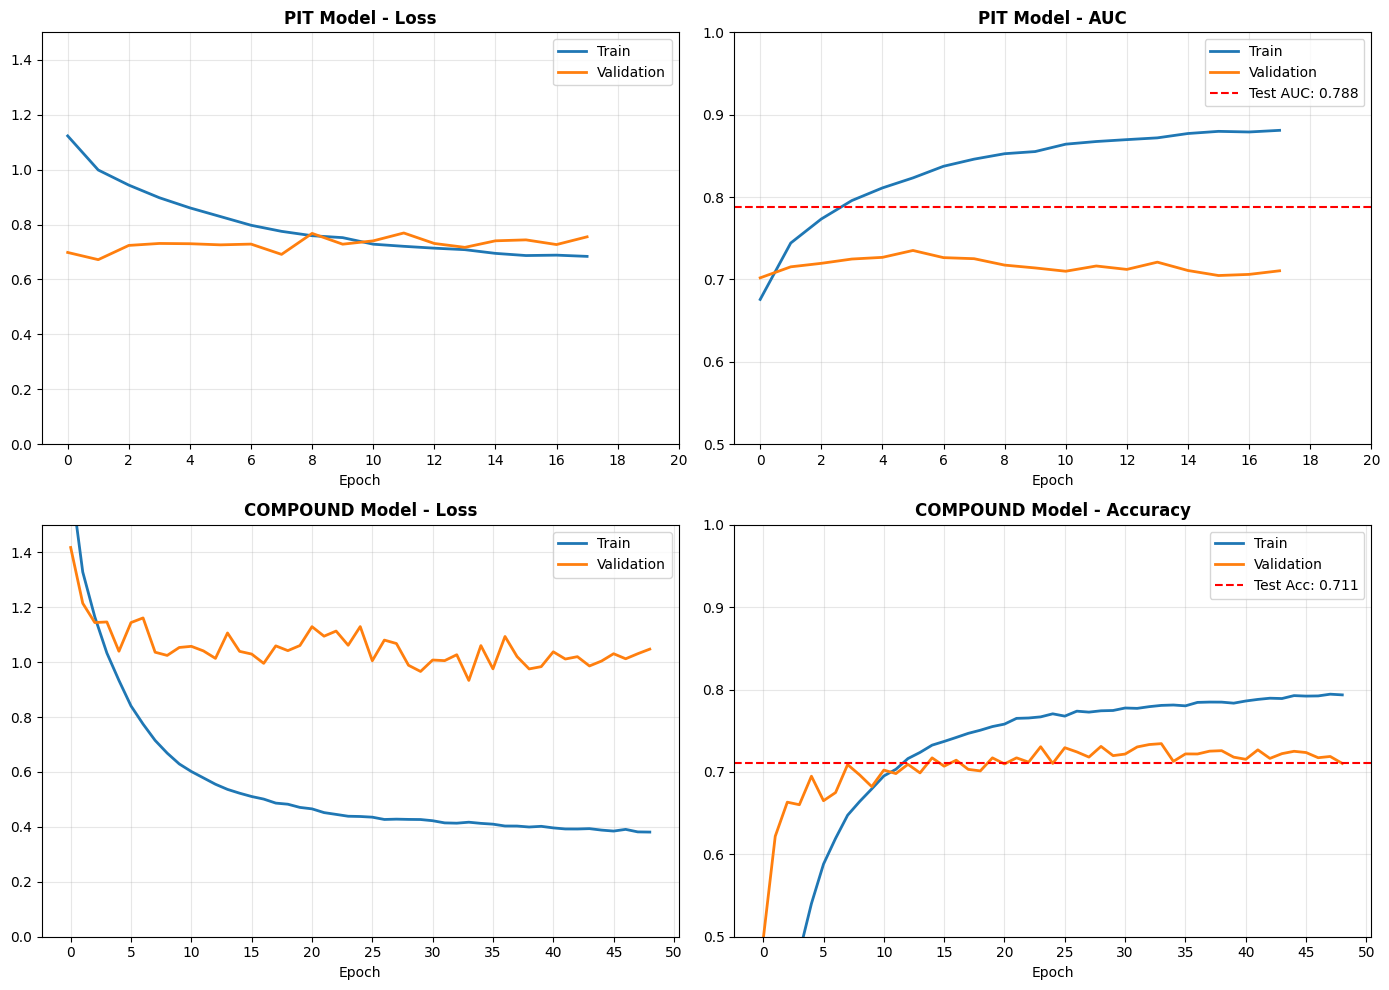

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
comEpochs = len(history_comp.history['loss'])
pitEpochs = len(history_pit.history['loss'])

# PIT - Loss
axes[0, 0].plot(history_pit.history['loss'], label='Train', linewidth=2)
axes[0, 0].plot(history_pit.history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('PIT Model - Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, int(pitEpochs)+1, int(pitEpochs/10)))
axes[0, 0].set_ylim(0, 1.5)


# PIT - AUC
axes[0, 1].plot(history_pit.history['auc'], label='Train', linewidth=2)
axes[0, 1].plot(history_pit.history['val_auc'], label='Validation', linewidth=2)
axes[0, 1].axhline(y=pit_auc, color='r', linestyle='--', label=f'Test AUC: {pit_auc:.3f}')
axes[0, 1].set_title('PIT Model - AUC', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(0, int(pitEpochs)+1, int(pitEpochs/10)))
axes[0, 1].set_ylim(0.5, 1.0)

# COMPOUND - Loss
axes[1, 0].plot(history_comp.history['loss'], label='Train', linewidth=2)
axes[1, 0].plot(history_comp.history['val_loss'], label='Validation', linewidth=2)
axes[1, 0].set_title('COMPOUND Model - Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(range(0, int(comEpochs)+1, int(comEpochs/10)))
axes[1, 0].set_ylim(0, 1.5)

# COMPOUND - Accuracy
axes[1, 1].plot(history_comp.history['accuracy'], label='Train', linewidth=2)
axes[1, 1].plot(history_comp.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 1].axhline(y=comp_acc, color='r', linestyle='--', label=f'Test Acc: {comp_acc:.3f}')
axes[1, 1].set_title('COMPOUND Model - Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(range(0, int(comEpochs)+1, int(comEpochs/10)))
axes[1, 1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig('Other/training_history.png', dpi=150, bbox_inches='tight')

---
# 7. Save

In [24]:
# Salva modelli Keras
model_pit4.save('Model/f1_pit_model.keras')
model_comp.save('Model/f1_compound_model.keras')

In [25]:
# Salva scaler e encoder
joblib.dump(scaler_pit, 'Model/f1_pit_scaler.pkl')
joblib.dump(scaler_comp, 'Model/f1_comp_scaler.pkl')
joblib.dump(label_encoder, 'Model/label_encoder.pkl')

['Model/label_encoder.pkl']

In [26]:
# Salva configurazione
config = {
    'sequence_length': SEQUENCE_LENGTH,
    'FEATURES': feat_pit,
    'FEATURES': feat_comp,
    'pit_threshold': float(opt_thresh),
    'compound_classes': list(label_encoder.classes_),
    'metrics': {
        'pit_auc': float(pit_auc),
        'pit_f1': float(pit_f1),
        'pit_accuracy': float(pit_acc),
        'compound_accuracy': float(comp_acc),
        'compound_f1': float(comp_f1)
    }
}

with open('Model/modelConfig.json', 'w') as f:
    json.dump(config, f, indent=2)

In [27]:
# Salva il dataset completo con tutte le features
df_f1.to_pickle('Other/f1_dataset_featured.pkl')

print(" Dataset con features salvato")

✓ Dataset con features salvato
